In [1]:
# Clone fresh
!git lfs install
!git clone https://huggingface.co/ctheodoris/Geneformer

# IMPORTANT: Change directory BEFORE installing
%cd /content/Geneformer

# Verify you're in the right place
!pwd
!ls -la  # Should see setup.py or pyproject.toml

# Now install
!pip install .

Git LFS initialized.
fatal: destination path 'Geneformer' already exists and is not an empty directory.
/content/Geneformer
/content/Geneformer
total 1235908
drwxr-xr-x 13 root root       4096 Jul 15 18:59 .
drwxr-xr-x  1 root root       4096 Jul 15 19:20 ..
drwxr-xr-x  4 root root       4096 Jul 15 18:59 build
-rw-r--r--  1 root root        591 Jul 15 18:58 config.json
drwxr-xr-x  3 root root       4096 Jul 15 18:58 docs
drwxr-xr-x  3 root root       4096 Jul 15 18:58 examples
drwxr-xr-x  3 root root       4096 Jul 15 18:58 fine_tuned_models
drwxr-xr-x  5 root root       4096 Jul 15 19:00 geneformer
drwxr-xr-x  2 root root       4096 Jul 15 18:59 geneformer.egg-info
drwxr-xr-x  2 root root       4096 Jul 15 18:58 Geneformer-V1-10M
drwxr-xr-x  2 root root       4096 Jul 15 18:58 Geneformer-V2-104M
drwxr-xr-x  2 root root       4096 Jul 15 18:58 Geneformer-V2-104M_CLcancer
drwxr-xr-x  2 root root       4096 Jul 15 18:58 Geneformer-V2-316M
-rw-r--r--  1 root root         90 Jul 15 18:58 

In [2]:
pip install -U transformers

In [3]:
import os
GPU_NUMBER = [i for i in range(1)] # please!!!!!!!! don't change this !!!!!!!! seems that parallel is not supported in hpc3.
os.environ["CUDA_VISIBLE_DEVICES"] = ",".join([str(s) for s in GPU_NUMBER])
print(os.environ["CUDA_VISIBLE_DEVICES"])
os.environ["NCCL_DEBUG"] = "INFO"
os.environ['CUDA_LAUNCH_BLOCKING'] ='1'
os.environ["NCCL_P2P_DISABLE"] = '1'

0


In [4]:
import torch
print(torch.cuda.device_count())
print(torch.__version__)

1
2.6.0+cu124


In [5]:
# imports
from collections import Counter
import datetime
import pickle
import subprocess
import seaborn as sns; sns.set()
from datasets import load_from_disk
from sklearn.metrics import accuracy_score, f1_score
from transformers import BertForSequenceClassification
from transformers import Trainer
from transformers.training_args import TrainingArguments
from geneformer import DataCollatorForCellClassification

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from geneformer import DataCollatorForCellClassification
from torch.utils.data import DataLoader

# Load the dataset
from datasets import load_from_disk
dataset = load_from_disk("/content/drive/My Drive/geneformer_test1/pbmc6_scanpy_with_ensembl_id/pbmc6_tokens.dataset")

# Inspect
print(dataset)
print(dataset[0])

# load cell type dataset (includes all tissues)
# materials : https://wang-lab.hkust.edu.hk/others/Tutorials/geneformer/readme.html

train_dataset = dataset     # other variable that I use in the script
original_dataset = dataset  # other variable that I use in the script

Dataset({
    features: ['input_ids', 'louvain', 'length'],
    num_rows: 5276
})
{'input_ids': [2, 3024, 17311, 12131, 11040, 10792, 17161, 7579, 4989, 5521, 4913, 11095, 15010, 664, 17782, 5908, 9881, 1775, 11321, 6279, 4606, 2044, 10197, 17617, 5861, 17941, 9661, 12413, 15372, 5456, 50, 7838, 15549, 1859, 12429, 401, 114, 5414, 17083, 4660, 6053, 14281, 11516, 15583, 17587, 3661, 6375, 5134, 1987, 14546, 12269, 7715, 3514, 12316, 777, 3103, 5567, 16419, 1329, 12616, 8552, 2620, 8213, 6337, 18803, 6868, 5004, 1858, 4407, 933, 2056, 7551, 2774, 4399, 2198, 7488, 12817, 5616, 7326, 8151, 14262, 11750, 4504, 3786, 14709, 1720, 12394, 18264, 8006, 18331, 12240, 16363, 8719, 2349, 8340, 4016, 1825, 2262, 11797, 242, 2112, 12484, 3626, 8706, 8497, 12990, 5177, 4626, 2644, 10525, 6668, 13069, 1387, 1505, 4440, 4792, 11771, 7180, 12391, 19277, 2756, 17983, 6186, 1617, 2974, 12552, 17554, 629, 10541, 18483, 2170, 6837, 14320, 2647, 10154, 15001, 2401, 7268, 5171, 1452, 4461, 17447, 9101, 1645

In [8]:
print("\n=== All Cell Metadata (First 5 Rows) ===")
first_rows = dataset[:5]
for key, value in first_rows.items():
    print(f"{key}: {value}")



=== All Cell Metadata (First 5 Rows) ===
input_ids: [[2, 3024, 17311, 12131, 11040, 10792, 17161, 7579, 4989, 5521, 4913, 11095, 15010, 664, 17782, 5908, 9881, 1775, 11321, 6279, 4606, 2044, 10197, 17617, 5861, 17941, 9661, 12413, 15372, 5456, 50, 7838, 15549, 1859, 12429, 401, 114, 5414, 17083, 4660, 6053, 14281, 11516, 15583, 17587, 3661, 6375, 5134, 1987, 14546, 12269, 7715, 3514, 12316, 777, 3103, 5567, 16419, 1329, 12616, 8552, 2620, 8213, 6337, 18803, 6868, 5004, 1858, 4407, 933, 2056, 7551, 2774, 4399, 2198, 7488, 12817, 5616, 7326, 8151, 14262, 11750, 4504, 3786, 14709, 1720, 12394, 18264, 8006, 18331, 12240, 16363, 8719, 2349, 8340, 4016, 1825, 2262, 11797, 242, 2112, 12484, 3626, 8706, 8497, 12990, 5177, 4626, 2644, 10525, 6668, 13069, 1387, 1505, 4440, 4792, 11771, 7180, 12391, 19277, 2756, 17983, 6186, 1617, 2974, 12552, 17554, 629, 10541, 18483, 2170, 6837, 14320, 2647, 10154, 15001, 2401, 7268, 5171, 1452, 4461, 17447, 9101, 16459, 13223, 18275, 13505, 10833, 11466, 6128

In [9]:
if "louvain" in dataset.features:
    print("✅ 'louvain' is present in the dataset.")
else:
    print("❌ 'louvain' is NOT present in the dataset.")

✅ 'louvain' is present in the dataset.


In [10]:
!pwd
!mkdir /content/pbmc6_tokens.dataset.train.test
%cd ..
%ls -1

/content/Geneformer
mkdir: cannot create directory ‘/content/pbmc6_tokens.dataset.train.test’: File exists
/content
drive/
Geneformer/
models/
pbmc6_embedding_output/
pbmc6_tokens.dataset.train.test/
sample_data/
wandb/


In [11]:
# Specific paths

token_dictionary = "/content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl"
model_v1 = "/content/Geneformer/Geneformer-V1-10M/"

dataset = load_from_disk("/content/drive/My Drive/geneformer_test1/pbmc6_scanpy_with_ensembl_id/pbmc6_tokens.dataset")
dataset_path = "/content/pbmc6_tokens.dataset.train.test"

import os
if os.path.isfile(token_dictionary):
    print("✅ File exists!")
else:
    print("❌ File NOT found.")

MODEL = model_v1

✅ File exists!


In [12]:
!ls -1 /content/Geneformer/
!ls -1 /content/Geneformer/Geneformer-V1-10M
!ls -1 /content/Geneformer/geneformer/gene_dictionaries_30m

build
config.json
docs
examples
fine_tuned_models
geneformer
geneformer.egg-info
Geneformer-V1-10M
Geneformer-V2-104M
Geneformer-V2-104M_CLcancer
Geneformer-V2-316M
generation_config.json
MANIFEST.in
model.safetensors
README.md
requirements.txt
setup.py
training_args.bin
config.json
model.safetensors
pytorch_model.bin
training_args.bin
ensembl_mapping_dict_gc30M.pkl
gene_median_dictionary_gc30M.pkl
gene_name_id_dict_gc30M.pkl
token_dictionary_gc30M.pkl


In [13]:
# 1. 🔍 View Cell Metadata
# List all metadata fields (columns)
# List all metadata fields (columns)
print(train_dataset.features)

# Preview values for the first few samples
print("\n=== Cell Metadata Examples ===")
for field in train_dataset.features:
    if field not in ['input_ids', 'length']:
        print(f"{field}: {train_dataset[:5][field]}")

# 2. View Gene Metadata (via Token Mapping)
# Each input_ids list contains token IDs that correspond to Ensembl IDs.
# To see the actual gene IDs:

import pickle

# Load your token dictionary (used during tokenization)
with open(token_dictionary, "rb") as f:
    token_dict = pickle.load(f)

data_collator = DataCollatorForCellClassification(token_dictionary = token_dict)

# Reverse it to map token ID → Ensembl ID
id_to_ensembl = {v: k for k, v in token_dict.items()}

# Example: decode gene tokens from one sample
token_ids = train_dataset[0]["input_ids"]
ensembl_ids = [id_to_ensembl.get(token, "SPECIAL_TOKEN") for token in token_ids]

# Show first 10 decoded gene IDs
print("\n=== Gene Tokens → Ensembl IDs ===")
print(ensembl_ids[:10])

{'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'louvain': Value(dtype='string', id=None), 'length': Value(dtype='int64', id=None)}

=== Cell Metadata Examples ===
louvain: ['CD4 T cells', 'B cells', 'CD4 T cells', 'CD14+ Monocytes', 'NK cells']

=== Gene Tokens → Ensembl IDs ===
['ENSG00000000003', 'ENSG00000105088', 'ENSG00000198914', 'ENSG00000167840', 'ENSG00000163701', 'ENSG00000162885', 'ENSG00000198585', 'ENSG00000138138', 'ENSG00000120057', 'ENSG00000124557']


**DataCollatorForCellClassification** is a custom data collator from the Geneformer package, specifically designed for single-cell tokenized data used in cell classification tasks.

It is used with Hugging Face’s Trainer API to:


*   Batch variable-length tokenized inputs (gene tokens)
*   Pad sequences properly
*   Add special tokens like <pad>, <mask>, etc., as needed
*   Ensure that input tensors are formatted correctly for the Geneformer model


Why You Need It :

In Hugging Face, a data collator is a function that:

* Takes a list of tokenized examples and
* Returns a batch dictionary (input_ids, attention_mask, labels, etc.)

But Geneformer sequences are not standard text, they are lists of Ensembl gene IDs mapped to tokens, so:

You can’t use the default Hugging Face DataCollatorWithPadding

You need a Geneformer-aware collator — hence DataCollatorForCellClassification

In [14]:
print(data_collator.__dict__)

{'token_dictionary': {'<pad>': 0, '<mask>': 1, 'ENSG00000000003': 2, 'ENSG00000000005': 3, 'ENSG00000000419': 4, 'ENSG00000000457': 5, 'ENSG00000000460': 6, 'ENSG00000000938': 7, 'ENSG00000000971': 8, 'ENSG00000001036': 9, 'ENSG00000001084': 10, 'ENSG00000001167': 11, 'ENSG00000001460': 12, 'ENSG00000001461': 13, 'ENSG00000001497': 14, 'ENSG00000001561': 15, 'ENSG00000001617': 16, 'ENSG00000001626': 17, 'ENSG00000001629': 18, 'ENSG00000001630': 19, 'ENSG00000001631': 20, 'ENSG00000002016': 21, 'ENSG00000002330': 22, 'ENSG00000002549': 23, 'ENSG00000002586': 24, 'ENSG00000002587': 25, 'ENSG00000002726': 26, 'ENSG00000002745': 27, 'ENSG00000002746': 28, 'ENSG00000002822': 29, 'ENSG00000002834': 30, 'ENSG00000002919': 31, 'ENSG00000002933': 32, 'ENSG00000003056': 33, 'ENSG00000003096': 34, 'ENSG00000003137': 35, 'ENSG00000003147': 36, 'ENSG00000003249': 37, 'ENSG00000003393': 38, 'ENSG00000003400': 39, 'ENSG00000003402': 40, 'ENSG00000003436': 41, 'ENSG00000003509': 42, 'ENSG00000003756':

In [15]:
print("\n=== All Fields in train_dataset (Top 5 Rows) ===")
top_rows = train_dataset[:5]

for field in train_dataset.features:
    print(f"{field}: {top_rows[field]}")


=== All Fields in train_dataset (Top 5 Rows) ===
input_ids: [[2, 3024, 17311, 12131, 11040, 10792, 17161, 7579, 4989, 5521, 4913, 11095, 15010, 664, 17782, 5908, 9881, 1775, 11321, 6279, 4606, 2044, 10197, 17617, 5861, 17941, 9661, 12413, 15372, 5456, 50, 7838, 15549, 1859, 12429, 401, 114, 5414, 17083, 4660, 6053, 14281, 11516, 15583, 17587, 3661, 6375, 5134, 1987, 14546, 12269, 7715, 3514, 12316, 777, 3103, 5567, 16419, 1329, 12616, 8552, 2620, 8213, 6337, 18803, 6868, 5004, 1858, 4407, 933, 2056, 7551, 2774, 4399, 2198, 7488, 12817, 5616, 7326, 8151, 14262, 11750, 4504, 3786, 14709, 1720, 12394, 18264, 8006, 18331, 12240, 16363, 8719, 2349, 8340, 4016, 1825, 2262, 11797, 242, 2112, 12484, 3626, 8706, 8497, 12990, 5177, 4626, 2644, 10525, 6668, 13069, 1387, 1505, 4440, 4792, 11771, 7180, 12391, 19277, 2756, 17983, 6186, 1617, 2974, 12552, 17554, 629, 10541, 18483, 2170, 6837, 14320, 2647, 10154, 15001, 2401, 7268, 5171, 1452, 4461, 17447, 9101, 16459, 13223, 18275, 13505, 10833, 114

In [16]:
# List all available cell-level metadata fields
print(train_dataset.features)

# View first 5 entries of a specific metadata field (e.g., 'organ' or 'louvain')
print("Organ metadata examples : ")
print(train_dataset[:5]["louvain"])     # if present

print(set(train_dataset["louvain"]))

# Step 1: List all fields (columns) in the dataset
print("=== 📋 Fields in train_dataset ===")
print(train_dataset.features)

# Step 2: Print metadata for first 5 cells (excluding token data)
print("\n=== 🧬 Cell Metadata (first 5 samples) ===")

# Loop through each feature that isn't input_ids or length
for field in train_dataset.features:
    if field not in ["input_ids", "length"]:
        print(f"\n🔹 {field}:")
        print(train_dataset[:5][field])


{'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'louvain': Value(dtype='string', id=None), 'length': Value(dtype='int64', id=None)}
Organ metadata examples : 
['CD4 T cells', 'B cells', 'CD4 T cells', 'CD14+ Monocytes', 'NK cells']
{'B cells', 'NK cells', 'CD8 T cells', 'CD4 T cells', 'FCGR3A+ Monocytes', 'Dendritic cells', 'Megakaryocytes', 'CD14+ Monocytes'}
=== 📋 Fields in train_dataset ===
{'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'louvain': Value(dtype='string', id=None), 'length': Value(dtype='int64', id=None)}

=== 🧬 Cell Metadata (first 5 samples) ===

🔹 louvain:
['CD4 T cells', 'B cells', 'CD4 T cells', 'CD14+ Monocytes', 'NK cells']


In [17]:
x = train_dataset.train_test_split(test_size=0.8, seed=42)
train_dataset = x["train"]  # use 10% of data to train
test_dataset = x["test"]
test_dataset.save_to_disk("/content/pbmc6_tokens.dataset.train.test")

In [18]:
!ls -1 /content/pbmc6_tokens.dataset.train.test

data-00000-of-00001.arrow
dataset_info.json
state.json


**BertForSequenceClassification**

BertForSequenceClassification is a specific implementation within the Hugging Face Transformers library designed to perform sequence classification tasks using the BERT (Bidirectional Encoder Representations from Transformers) model. 🤖 It's one of the most commonly used classes for text classification problems because it leverages BERT's powerful understanding of language.

What it Does :

At its core, BertForSequenceClassification takes a pre-trained BERT model and adds a classification head on top of it.

Here's a breakdown:

**Pre-trained BERT Encoder: **The vast majority of the model is the original BERT architecture, which has been pre-trained on a massive amount of text data (like Wikipedia and Google Books). This pre-training allows BERT to learn rich, contextualized representations of words and sentences. It understands grammar, semantics, and relationships between words.

**Classification Head:** On top of this powerful encoder, a relatively small, task-specific neural network layer is added.

This **"head"** typically consists of:

*A dropout layer:* This helps prevent overfitting during fine-tuning.

*A linear layer (dense layer)*: This layer takes the output representation of the entire input sequence from the BERT encoder (usually the representation of the [CLS] token, which is designed to aggregate sequence-level information) and projects it to the number of output classes you specify.

The output of this linear layer represents *the logits for each class*. These logits are raw, unnormalized scores that are then typically passed through a *softmax function* to get probabilities for each class.



**Why Use It?**

**Transfer Learning:**

 The biggest advantage is transfer learning. Instead of training a language model from scratch (which requires immense data and computational power), you start with a model that already "knows" a lot about language. You then fine-tune it on your specific, smaller dataset. This saves time, resources, and often leads to better performance.

**Contextual Embeddings:**

BERT generates contextual embeddings. *This means the representation of a word changes based on the other words around it in the sentence.* For example, the word "bank" in "river bank" will have a different embedding than "bank" in "financial bank." This deep understanding is crucial for nuanced classification tasks.

Ease of Use: Hugging Face's API makes it incredibly easy to load, use, and fine-tune BertForSequenceClassification models with just a few lines of code.

**How it Works (Under the Hood)**

When you pass your tokenized input ( input_ids, attention_mask, and optionally token_type_ids) to BertForSequenceClassification:

**Embedding Layer:** The input_ids are converted into **token embeddings**, s**egment embeddings** (if token_type_ids are used), and **positional embeddings**, which are then summed.

**Transformer Encoder Layers:** These combined embeddings pass through multiple layers of Transformer encoder blocks. *Each block applies self-attention mechanisms and feed-forward networks, refining the contextual representation of each token.*

**Pooled Output:** The output of the final Transformer layer corresponding to the [CLS] token (the first token in the sequence) is typically used as the aggregated representation of the entire sequence. *This is often referred to as the "pooled output."*

**Classification Head:** This pooled output is then fed into the added classification head (dropout + linear layer) to produce the raw logits for your specified number of classes.

**Loss Calculation (during training): **If you provide labels during the forward pass, BertForSequenceClassification will also compute a cross-entropy loss between the predicted logits and the true labels. This loss is what's minimized during the fine-tuning process.


**Common Use Cases**

BertForSequenceClassification is the go-to choice for almost any task where you need to categorize an entire piece of text. Examples include:

**Sentiment Analysis:**

Classifying movie reviews, social media posts, or product feedback as positive, negative, or neutral.

**Spam Detection:**

Identifying emails or messages as spam or legitimate.

**Abuse Detection:**

Flagging hate speech, offensive content, or cyberbullying.

**Topic Classification:**

Assigning news articles, documents, or blog posts to predefined categories (e.g., "Sports," "Politics," "Technology").

**Intent Recognition:**

Understanding the user's goal in a conversational AI system (e.g., "Book a flight," "Check weather").

**⚙️ Architecture**

```
Input: [CLS] + tokens + [SEP]
↓
BERT Encoder (12 or more layers)
↓
[CLS] Token Output → Linear Layer → Softmax/Logits

```

The model uses the representation of the [CLS] token (first token) to make classification decisions.

Output: a tensor of shape (batch_size, num_labels) with raw scores (logits) for each class.

**🛠️ Key Parameters**

```
BertForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path,
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)
```

pretrained_model_name_or_path: e.g. "bert-base-uncased"

*num_labels:* Number of output classes (2 for binary classification)

*output_attentions:* Whether to output attention weights

*output_hidden_states:* Whether to output hidden states from all layers

In [19]:
# MODEL PARAMETERS to start with :
# proposed by : https://wang-lab.hkust.edu.hk/others/Tutorials/geneformer/PBMC.2.finetune.html

# max input size
# max_input_size = 2 ** 11  # 2048

# set training hyperparameters
# max learning rate
# max_lr = 5e-5

# how many pretrained layers to freeze
# freeze_layers = 0

# number gpus
# num_gpus = 1

# number cpu cores
# num_proc = 16

# batch size for training and eval
# geneformer_batch_size = 5    #for 3090, 5 is maximum.

# learning schedule
# lr_schedule_fn = "linear"

# warmup steps
# warmup_steps = 500

# number of epochs
# epochs = 10

# optimizer
# optimizer = "adamw"

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    # calculate accuracy and macro f1 using sklearn's function
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average='macro')
    return {
      'accuracy': acc,
      'macro_f1': macro_f1
    }

In [20]:
from transformers import BertForSequenceClassification, TrainingArguments, Trainer
from geneformer import DataCollatorForCellClassification
from datasets import load_from_disk
from collections import Counter
import datetime
import os
import pickle
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# ============================================================================
# DATA PREP
# ============================================================================

# Load and prepare dataset (callet dataset, or original_dataset)
# original_dataset = load_from_disk("/content/drive/My Drive/geneformer_test1/pbmc6_scanpy_with_ensembl_id/pbmc6_tokens.dataset")

x = original_dataset.train_test_split(test_size=0.8, seed=42)
train_data = x["train"]

# Create label mapping for Louvain
louvain_counter = Counter(train_data["louvain"])
clusters_to_keep = [k for k, v in louvain_counter.items() if v > len(train_data) * 0.005]
filtered_data = train_data.filter(lambda x: x["louvain"] in clusters_to_keep, num_proc=16)
shuffled_data = filtered_data.shuffle(seed=42).rename_column("louvain", "label")

# Create numerical labels
target_names = sorted(list(set(shuffled_data["label"])))
louvain_label_dict = {name: idx for idx, name in enumerate(target_names)}
def map_labels(example):
    example["label"] = louvain_label_dict[example["label"]]
    return example
labeled_data = shuffled_data.map(map_labels, num_proc=16)

# Train/eval split
train_size = round(len(labeled_data) * 0.8)
louvain_trainset = labeled_data.select(range(train_size))
louvain_evalset = labeled_data.select(range(train_size, len(labeled_data)))

# ============================================================================
# SIMPLE TRAINING
# ============================================================================

# Hyperparameters
max_input_size = 2048
geneformer_batch_size = 5
max_lr = 5e-5
lr_schedule_fn = "linear"
warmup_steps = 500
epochs = 30
optimizer = "adamw"
freeze_layers = 0

# ============================================================================
# TRAINING LOOP
# ============================================================================

print("louvain")

# We use: louvain_trainset (already prepared above)
# We use: louvain_evalset (already prepared above)
# We use: louvain_label_dict (already prepared above)

# set logging steps
logging_steps = round(len(louvain_trainset)/geneformer_batch_size/10)

# reload pretrained model
model = BertForSequenceClassification.from_pretrained(MODEL,
                                                      num_labels = len(louvain_label_dict.keys()),  # not hardcoded to 2
                                                      output_attentions = False,
                                                      output_hidden_states=False).to("cuda")

# define output directory path
current_date = datetime.datetime.now()
datestamp = f"{str(current_date.year)[-2:]}{current_date.month:02d}{current_date.day:02d}"
output_dir = f"/content/models/{datestamp}_geneformer_CellClassifier_louvain_L{max_input_size}_B{geneformer_batch_size}_LR{max_lr}_LS{lr_schedule_fn}_WU{warmup_steps}_E{epochs}_O{optimizer}_F{freeze_layers}/"

# ensure not overwriting previously saved model
saved_model_test = os.path.join(output_dir, f"pytorch_model.bin")
if os.path.isfile(saved_model_test) == True:
    raise Exception("Model already saved to this directory.")

# make output directory
os.makedirs(output_dir, exist_ok=True)

# set training arguments
training_args = {
    "learning_rate": max_lr,
    "do_train": True,
    "do_eval": True,
    "eval_strategy": "epoch",
    "save_strategy": "epoch",
    "logging_steps": logging_steps,
    "group_by_length": True,
    "length_column_name": "length",
    "disable_tqdm": False,
    "lr_scheduler_type": lr_schedule_fn,
    "warmup_steps": warmup_steps,
    "weight_decay": 0.001,
    "per_device_train_batch_size": geneformer_batch_size,
    "per_device_eval_batch_size": geneformer_batch_size,
    "num_train_epochs": epochs,
    "load_best_model_at_end": True,
    "output_dir": output_dir,
}

training_args_init = TrainingArguments(**training_args)

# DataCollatorForCellClassification expects the actual dictionary object, not the file‑path string.
# Load the pickle file first, store it in (e.g.) token_dict, and pass that variable to the collator:
# Load your token dictionary (used during tokenization)
with open(token_dictionary, "rb") as f:
    token_dict = pickle.load(f)
data_collator = DataCollatorForCellClassification(token_dictionary = token_dict)

# create the trainer
trainer = Trainer(
    model = model,
    args = training_args_init,
    data_collator = DataCollatorForCellClassification(token_dictionary = token_dict),  # added token_dictionary
    train_dataset = louvain_trainset,    # trainset
    eval_dataset = louvain_evalset,      # evalset
    compute_metrics = compute_metrics
)

# train the cell type classifier
trainer.train()
predictions = trainer.predict(louvain_evalset)
with open(f"{output_dir}predictions.pickle", "wb") as fp:
    pickle.dump(predictions, fp)
trainer.save_metrics("eval", predictions.metrics)
trainer.save_model(output_dir)

print("✅ Training complete!")
print(f"Model saved to: {output_dir}")

# Quick results
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = louvain_evalset["label"]
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')
print(f"Accuracy: {accuracy:.3f}, F1: {f1:.3f}")


/usr/local/lib/python3.11/dist-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)
/usr/local/lib/python3.11/dist-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /content/Geneformer/Geneformer-V1-10M/ and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


louvain


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Currently logged in as: tanasa (tanasa-sb) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/content/Geneformer/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch = {k: torch.tensor(v.clone().detach(), dtype=torch.int64) if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=torch.int64) for k, v in batch.items()}


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.786400,1.739165,0.426540,0.074751
2,1.796600,1.692750,0.426540,0.074751
3,1.608900,1.692834,0.426540,0.074751
4,1.660600,1.685818,0.426540,0.074751
5,1.627600,1.690722,0.426540,0.074751
6,1.682500,1.653796,0.426540,0.074751
7,1.513700,1.583920,0.521327,0.233574
8,1.380700,1.752566,0.317536,0.165462
9,1.172200,1.290034,0.587678,0.266387
10,1.185100,1.229275,0.587678,0.290869


/content/Geneformer/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch = {k: torch.tensor(v.clone().detach(), dtype=torch.int64) if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=torch.int64) for k, v in batch.items()}
/content/Geneformer/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch = {k: torch.tensor(v.clone().detach(), dtype=torch.int64) if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=torch.int64) for k, v in batch.items()}
/content/Geneformer/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTe

✅ Training complete!
Model saved to: /content/models/250715_geneformer_CellClassifier_louvain_L2048_B5_LR5e-05_LSlinear_WU500_E30_Oadamw_F0/
Accuracy: 0.256, F1: 0.105


In [21]:
# Print number of tokens
print("Total tokens in dictionary:", len(token_dict))

# Show the first 10 items
print("\n=== Sample from token_dict ===")
for i, (k, v) in enumerate(token_dict.items()):
    print(f"{k} --> {v}")
    if i >= 9:
        break

# The collator will extract these from token_dict after it's used at least once.
# So first, call it with a small batch:

# Trigger initialization of the collator
_ = data_collator([louvain_trainset[0]])

# Now inspect internal token IDs
print("PAD token ID:", token_dict.get("<pad>"))
print("MASK token ID:", token_dict.get("<mask>"))
print("CLS token ID:", token_dict.get("<cls>", "not found"))
print("SEP token ID:", token_dict.get("<sep>", "not found"))
print("All special tokens found:")
print([k for k in token_dict.keys() if "<" in k and ">" in k])

Total tokens in dictionary: 25426

=== Sample from token_dict ===
<pad> --> 0
<mask> --> 1
ENSG00000000003 --> 2
ENSG00000000005 --> 3
ENSG00000000419 --> 4
ENSG00000000457 --> 5
ENSG00000000460 --> 6
ENSG00000000938 --> 7
ENSG00000000971 --> 8
ENSG00000001036 --> 9
PAD token ID: 0
MASK token ID: 1
CLS token ID: not found
SEP token ID: not found
All special tokens found:
['<pad>', '<mask>']


/content/Geneformer/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch = {k: torch.tensor(v.clone().detach(), dtype=torch.int64) if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=torch.int64) for k, v in batch.items()}



```
trainer = Trainer(
    model = model,
    args = training_args_init,
    data_collator = DataCollatorForCellClassification(token_dictionary=token_dict),
    train_dataset = louvain_trainset,
    eval_dataset = louvain_evalset,
    compute_metrics = compute_metrics
)
```

creates an instance of Hugging Face's Trainer — a high-level training utility that simplifies model fine-tuning, evaluation, checkpointing, and logging.

🧠 Breakdown of Each Argument

**✅ model=model**

This is your instance of BertForSequenceClassification — in this case, a Geneformer model fine-tuned for cell classification.
It's the core neural network that receives tokenized gene input and outputs class predictions (e.g., Louvain clusters).

**✅ args=training_args_init**

This is an instance of TrainingArguments which holds all training-related hyperparameters like:

*Learning rate*

*Batch size*

*Number of epochs*

*Output directory*

*Save and logging strategy*


Explaining the code above :

Load your token dictionary (used during tokenization)

```
with open(token_dictionary, "rb") as f:
    token_dict = pickle.load(f)

```

```
data_collator = DataCollatorForCellClassification(token_dictionary = token_dict)
print(data_collator)

```


```
TrainingArguments(
    learning_rate=5e-5,
    per_device_train_batch_size=5,
    num_train_epochs=10,
    output_dir="/content/models/...",
    evaluation_strategy="epoch",
    logging_steps=50,
    ...
)
```

**✅ data_collator=DataCollatorForCellClassification(...)**

This handles how batches are assembled during training.

*It takes your tokenized single-cell examples and:*

*Pads them to equal length*

*Adds attention masks*

*Returns a batch of tensors in the correct format*

*It’s Geneformer-specific and uses the provided token_dict to identify special tokens like <pad> and <mask>.*

Without this, Trainer wouldn't know how to batch variable-length gene token sequences.

**✅ train_dataset=louvain_trainset**

This is your training data — a Hugging Face Dataset where each row contains:

*input_ids: tokenized genes*

*length: original sequence length*

*label: numeric Louvain cluster class*

Example (json):

{
  "input_ids": [1049, 392, 2842, ...],
  "length": 189,
  "label": 3
}

**✅ eval_dataset=louvain_evalset**

The validation set — same structure as training set, used to:

Evaluate performance after each epoch

Monitor accuracy and F1 score

Save the best model

**✅ compute_metrics=compute_metrics**

```
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro')
    }

```


It lets Trainer compute meaningful metrics beyond just loss — in your case:

**Accuracy**

**Macro F1 (important for imbalanced classes)**

🧪 What Trainer Does

Once you call trainer.train(), it:

*Automatically handles forward/backward pass*

*Evaluates on eval_dataset after each epoch*

*Saves the best model (if configured)*

*Logs progress and metrics*

*Supports GPU training and mixed precision (if enabled)*

How padding and masking work in Geneformer (or any BERT-like model):

🧬 Scenario

Your sequences are lists of gene token IDs (e.g., Ensembl IDs like ENSG00000139618 mapped to integers).

**Your <pad> token ID is 0**

**Your <mask> token ID is 1**

These special tokens are defined in your token_dict.

🎯 Purpose

**Padding (<pad> → ID 0):**

Ensures that all input sequences in a batch have the same length by filling shorter sequences with a padding token (ID 0 in your case).

**Masking (<mask> → ID 1):**

Optionally replaces some tokens in the input with a <mask> token (ID 1) for masked language modeling, data augmentation, or self-supervised tasks — not typically used during classification.

🔢 Concrete Example

Suppose we have 3 tokenized cells (gene ID sequences) like:

```
cell_1 = [83, 1052, 27, 302]
cell_2 = [79, 49]
cell_3 = [1502, 9, 88]
```

These sequences have lengths:

4 (cell_1)

2 (cell_2)

3 (cell_3)

To create a batch, we pad them all to the max length (4), using <pad> token ID 0:

```
**➕ Padded input_ids**

cell_1: [  83, 1052,   27,  302]
cell_2: [  79,   49,    0,    0]
cell_3: [1502,    9,   88,    0]
```

🎭 Corresponding attention_mask

```
cell_1: [1, 1, 1, 1]
cell_2: [1, 1, 0, 0]
cell_3: [1, 1, 1, 0]
🔹 1 = real token
🔹 0 = ignore this token during model attention
```

The model will not compute attention over padded tokens, nor will it update their hidden states meaningfully.

**🎭 Optional: Masking (if applied)**

You might replace one of the real gene tokens with <mask> (ID 1) during training:

cell_1: [83, 1052, 1, 302]  ← token at position 2 masked

This is common in pretraining, not typically in fine-tuning unless doing adversarial or robust training.

**✅ What the Model Receives**

For each batch, the DataCollatorForCellClassification provides:

**input_ids:** padded list of gene token IDs

**attention_mask:** marks which tokens are real

**labels:** the class labels for each cell

```
{
  "input_ids":       [[83, 1052, 27, 302], [79, 49, 0, 0], [1502, 9, 88, 0]],
  "attention_mask":  [[ 1,    1,  1,   1], [ 1,  1, 0, 0], [  1,  1,  1, 0]],
  "labels":          [3, 0, 2]
}

```

**DataCollatorForCellClassification(token_dictionary=token_dict)**

What: Prepares cell data for training

Like: Chef who portions ingredients correctly

Does:

*Pads sequences to same length*

*Creates batches of cells*

*Handles special tokens (PAD, MASK, etc.)*

In [22]:
!ls -1
!ls -1 /content/models/
!ls -1 /content/wandb/
!echo -e "content of the classifier folder"


drive
Geneformer
models
pbmc6_embedding_output
pbmc6_tokens.dataset.train.test
sample_data
wandb
250715_geneformer_CellClassifier_louvain_L2048_B5_LR5e-05_LSlinear_WU500_E30_Oadamw_F0
debug-internal.log
debug.log
latest-run
run-20250715_190933-ouf503l4
run-20250715_192856-5wncdljq
content of the classifier folder


In [23]:
!ls -1 /content/models/250715_geneformer_CellClassifier_louvain_L2048_B5_LR5e-05_LSlinear_WU500_E30_Oadamw_F0
!ls -1 /content/models/250715_geneformer_CellClassifier_louvain_L2048_B5_LR5e-05_LSlinear_WU500_E30_Oadamw_F0/runs

all_results.json
checkpoint-1014
checkpoint-1183
checkpoint-1352
checkpoint-1521
checkpoint-169
checkpoint-1690
checkpoint-1859
checkpoint-2028
checkpoint-2197
checkpoint-2366
checkpoint-2535
checkpoint-2704
checkpoint-2873
checkpoint-3042
checkpoint-3211
checkpoint-338
checkpoint-3380
checkpoint-3549
checkpoint-3718
checkpoint-3887
checkpoint-4056
checkpoint-4225
checkpoint-4394
checkpoint-4563
checkpoint-4732
checkpoint-4901
checkpoint-507
checkpoint-5070
checkpoint-676
checkpoint-845
config.json
eval_results.json
model.safetensors
predictions.pickle
runs
training_args.bin
Jul15_19-08-59_139e014c6004
Jul15_19-28-52_139e014c6004


📦 What Gets Saved

```
with open(f"{output_dir}predictions.pickle", "wb") as fp:
    pickle.dump(predictions, fp)

```

**✅ 1. predictions.pickle**

You store the prediction object (logits, labels, metrics, etc.) to a file, so you can reuse it later.

trainer.save_metrics("eval", predictions.metrics)

**✅ 2. eval_results.json**

This writes a JSON file inside output_dir (e.g., eval_results.json) containing metrics like accuracy, F1-score, etc.

trainer.save_model(output_dir)

**✅ 3. output_dir/** → Fine-tuned Model is Saved Here

It saves:

*pytorch_model.bin: model weights*

*config.json: model configuration*

*tokenizer_config.json and/or vocab (optional)*

*trainer_state.json: trainer checkpoint state*

You can later reload this fine-tuned model with:

```
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(output_dir)

```

✅ Summary

File or Folder	     : Purpose

predictions.pickle	 : All predictions and metadata from eval

eval_results.json	   : Metrics like accuracy, saved by Trainer

output_dir/ folder	 : Fine-tuned model weights + configs

pytorch_model.bin	   : Main saved model (used for inference later)

**Visualize the output files :**

In [24]:
import json

with open(f"{output_dir}/eval_results.json", "r") as f:
    results = json.load(f)
    print(json.dumps(results, indent=2))

{
  "test_accuracy": 0.7014218009478673,
  "test_loss": 1.0278139114379883,
  "test_macro_f1": 0.4777335871163558,
  "test_runtime": 0.9899,
  "test_samples_per_second": 213.153,
  "test_steps_per_second": 43.439
}


In [25]:
import pickle

with open(f"{output_dir}/predictions.pickle", "rb") as f:
    predictions = pickle.load(f)

print("Available attributes in PredictionOutput:")
print(dir(predictions))  # or use predictions._fields if it's a namedtuple

print("\nPredictions (logits) shape:")
print(predictions.predictions.shape)

print("\nTrue labels:")
print(predictions.label_ids[:10])

print("\nEvaluation metrics:")
print(predictions.metrics)


# Convert logits to predicted class index
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

import numpy as np
import pandas as pd
df_preds = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred,
    "confidence": predictions.predictions.max(axis=1)
})

print(df_preds.head())

Available attributes in PredictionOutput:
['__add__', '__annotations__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__match_args__', '__module__', '__mul__', '__ne__', '__new__', '__orig_bases__', '__reduce__', '__reduce_ex__', '__repr__', '__rmul__', '__setattr__', '__sizeof__', '__slotnames__', '__slots__', '__str__', '__subclasshook__', '_asdict', '_field_defaults', '_fields', '_make', '_replace', 'count', 'index', 'label_ids', 'metrics', 'predictions']

Predictions (logits) shape:
(211, 8)

True labels:
[2 5 2 2 1 2 5 2 3 2]

Evaluation metrics:
{'test_loss': 1.0278139114379883, 'test_accuracy': 0.7014218009478673, 'test_macro_f1': 0.4777335871163558, 'test_runtime': 0.9899, 'test_samples_per_second': 213.153, 'test_steps_per_second': 43.43

In [26]:
import json

with open(f"{output_dir}/all_results.json", "r") as f:
    results2 = json.load(f)

print("📊 all_results.json")
print(json.dumps(results2, indent=2))


📊 all_results.json
{
  "test_accuracy": 0.7014218009478673,
  "test_loss": 1.0278139114379883,
  "test_macro_f1": 0.4777335871163558,
  "test_runtime": 0.9899,
  "test_samples_per_second": 213.153,
  "test_steps_per_second": 43.439
}


The file **model.safetensors** is a serialized file containing the trained weights of your model, saved using the SafeTensors format.

It is used instead of the traditional PyTorch .bin files (pytorch_model.bin) for safety, speed, and interoperability.



In [27]:
from safetensors import safe_open

with safe_open(f"{output_dir}/model.safetensors", framework="pt") as f:
    print("Keys in the model:", f.keys())
    tensor = f.get_tensor("bert.encoder.layer.0.attention.self.query.weight")
    print(tensor.shape)


Keys in the model: ['bert.embeddings.LayerNorm.bias', 'bert.embeddings.LayerNorm.weight', 'bert.embeddings.position_embeddings.weight', 'bert.embeddings.token_type_embeddings.weight', 'bert.embeddings.word_embeddings.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.dense.bias', 'bert.encoder.layer.0.attention.output.dense.weight', 'bert.encoder.layer.0.attention.self.key.bias', 'bert.encoder.layer.0.attention.self.key.weight', 'bert.encoder.layer.0.attention.self.query.bias', 'bert.encoder.layer.0.attention.self.query.weight', 'bert.encoder.layer.0.attention.self.value.bias', 'bert.encoder.layer.0.attention.self.value.weight', 'bert.encoder.layer.0.intermediate.dense.bias', 'bert.encoder.layer.0.intermediate.dense.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.dense.bias', 'bert.encoder.laye

An example :

'bert.encoder.layer.0.attention.output.dense.bias',

'bert.encoder.layer.0.attention.output.dense.weight',
...

refers to **the names of the parameters (weights and biases) in your BERT model architecture **— specifically, inside the first transformer layer.

'bert.encoder.layer.0.output.dense.weight'

'bert.encoder.layer.0.output.dense.bias'

'bert.encoder.layer.0.output.LayerNorm.weight'

are all part of **the feed-forward + residual + normalization block** that comes after the attention sub-layer in each transformer block of BERT.

The file **training_args.bin** is a serialized snapshot of your training configuration, saved automatically by Hugging Face's Trainer.

*📦 What is training_args.bin?*

It contains all the values passed to TrainingArguments, which control:

Category	Examples

Paths	output_dir, logging_dir, eval_strategy, etc.
Training setup	  : learning_rate, per_device_train_batch_size, epochs
Scheduling	      : warmup_steps, lr_scheduler_type
Evaluation	      : save_strategy, eval_steps, metric_for_best_model
Device & logging	: fp16, logging_steps, report_to

In [28]:
import torch
from transformers import TrainingArguments
from transformers.trainer_utils import IntervalStrategy

# ✅ Allow safe unpickling of HuggingFace classes
torch.serialization.add_safe_globals([TrainingArguments, IntervalStrategy])

# ✅ Now load the serialized training arguments
args = torch.load(f"{output_dir}/training_args.bin", weights_only=False)

# ✅ Print all arguments
print("=== TrainingArguments ===")
for key, value in vars(args).items():
    print(f"{key}: {value}")


=== TrainingArguments ===
output_dir: /content/models/250715_geneformer_CellClassifier_louvain_L2048_B5_LR5e-05_LSlinear_WU500_E30_Oadamw_F0/
overwrite_output_dir: False
do_train: True
do_eval: True
do_predict: False
eval_strategy: IntervalStrategy.EPOCH
prediction_loss_only: False
per_device_train_batch_size: 5
per_device_eval_batch_size: 5
per_gpu_train_batch_size: None
per_gpu_eval_batch_size: None
gradient_accumulation_steps: 1
eval_accumulation_steps: None
eval_delay: 0
torch_empty_cache_steps: None
learning_rate: 5e-05
weight_decay: 0.001
adam_beta1: 0.9
adam_beta2: 0.999
adam_epsilon: 1e-08
max_grad_norm: 1.0
num_train_epochs: 30
max_steps: -1
lr_scheduler_type: SchedulerType.LINEAR
lr_scheduler_kwargs: {}
warmup_ratio: 0.0
warmup_steps: 500
log_level: passive
log_level_replica: warning
log_on_each_node: True
logging_dir: /content/models/250715_geneformer_CellClassifier_louvain_L2048_B5_LR5e-05_LSlinear_WU500_E30_Oadamw_F0/runs/Jul15_19-28-52_139e014c6004
logging_strategy: Inter

I have also followed the code described in :

https://wang-lab.hkust.edu.hk/others/Tutorials/geneformer/readme.html

https://wang-lab.hkust.edu.hk/others/Tutorials/geneformer/tokenizing_scRNAseq_data-2.html

https://wang-lab.hkust.edu.hk/others/Tutorials/geneformer/PBMC.2.finetune.html

https://wang-lab.hkust.edu.hk/others/Tutorials/geneformer/PBMC.3.extract_embedding.html

**Embeddings :**

In Geneformer, embeddings are numerical vector representations of entire cells based on their transcriptomic profile. Think of them as compact summaries that encode the biologically relevant information in the expression of a cell — in a way the model can understand.

These embeddings are:

**Contextualized:** Like BERT does with words, Geneformer builds these embeddings by looking at how all genes in the cell relate to each other.

**Learned:** They're extracted from the final hidden states of the transformer model (e.g., layer -1) after passing the tokenized transcriptomic input through the model.

Useful for downstream tasks: Such as clustering, UMAP/tSNE visualization, classification, trajectory inference, etc.

Let’s walk through a cell's journey:

*You input a tokenized cell: It’s a list of genes (as tokens) sorted by expression level.*

*Geneformer passes it through the transformer layers.*

*Each gene gets a vector from each layer (like in BERT).*

*The model aggregates them into a cell-level embedding.*

*Usually, this is done by averaging or pooling gene vectors.*

**That vector is your cell embedding: a fixed-length vector (e.g. 768-dimension) that captures transcriptomic identity.**

 Geneformer supports both **cell embeddings and gene embeddings** — and they serve different, but complementary purposes.

**🔬 Cell Embeddings vs Gene Embeddings**

Type	Description

**Cell Embeddings**	A vector representing the whole cell, aggregated from the tokens (genes) in its transcriptomic profile. Extracted using the EmbExtractor.

**Gene Embeddings	**A vector representing each gene token — its contextualized role within the cell. These come from the transformer’s internal representation of tokens.

**🧬 What are gene embeddings in Geneformer?**

Gene embeddings in Geneformer are:

Learned vector representations of individual genes (tokens).

Contextual — meaning they depend on the cell in which the gene appears and its co-expression with other genes.

Usually of *dimension 768 (or whatever the hidden size of your model is).*

Extracted per gene token (e.g., ENSG00000123456) per cell.

⚙️ How to extract gene embeddings? (GPT4, it might have been updated ?)

Does geneformer offesr a built-in high-level utility like EmbExtractor for gene embeddings ?

To extract cell embeddings using your fine-tuned Geneformer model with the EmbExtractor utility, here's how you should proceed b
✅ Step-by-step to Extract Cell Embeddings

You already have:

✅ A fine-tuned model saved in output_dir (e.g., /content/models/250715_geneformer_CellClassifier_louvain_...)

✅ A tokenized dataset (e.g., pbmc6_tokens.dataset.train.test)

✅ A properly initialized EmbExtractor object


In a newer version of Geneformer :

**geneformer.emb_extractor**

https://geneformer.readthedocs.io/en/latest/geneformer.emb_extractor.html

`classEmbExtractor(model_type='Pretrained', num_classes=0, emb_mode='cls', cell_emb_style='mean_pool', gene_emb_style='mean_pool', filter_data=None, max_ncells=1000, emb_layer=-1, emb_label=None, labels_to_plot=None, forward_batch_size=100, nproc=4, summary_stat=None, model_version='V2', token_dictionary_file=None)`

Initialize embedding extractor.

Parameters:

`model_type{“Pretrained”, “GeneClassifier”, “CellClassifier”, “Pretrained-Quantized”}`

Whether model is the pretrained Geneformer (full or quantized) or a fine-tuned gene or cell classifier.

`num_classesint`

If model is a gene or cell classifier, specify number of classes it was trained to classify.

For the pretrained Geneformer model, number of classes is 0 as it is not a classifier.

`emb_mode{“cls”, “cell”, “gene”}`

Whether to output CLS, cell, or gene embeddings.
CLS embeddings are cell embeddings derived from the CLS token in the front of the rank value encoding.

`cell_emb_style{“mean_pool”}`

Method for summarizing cell embeddings if not using CLS token.
Currently only option is mean pooling of gene embeddings for given cell.

`gene_emb_style“mean_pool”`

Method for summarizing gene embeddings.
Currently only option is mean pooling of contextual gene embeddings for given gene.

`filter_dataNone, dict`

Default is to extract embeddings from all input data.
Otherwise, dictionary specifying .dataset column name and list of values to filter by.

`max_ncellsNone, int`

Maximum number of cells to extract embeddings from.
Default is 1000 cells randomly sampled from input data.
If None, will extract embeddings from all cells.

`emb_layer{-1, 0}`

Embedding layer to extract.
The last layer is most specifically weighted to optimize the given learning objective.
Generally, it is best to extract the 2nd to last layer to get a more general representation.

-1: 2nd to last layer
0: last layer

`summary_stat{None, “mean”, “median”, “exact_mean”, “exact_median”}`

If exact_mean or exact_median, outputs only exact mean or median embedding of input data.

If mean or median, outputs only approximated mean or median embedding of input data.

Non-exact recommended if encountering memory constraints while generating goal embedding positions.


`model_versionstr`

To auto-select settings for model version other than current default.

Current options: V1: models pretrained on ~30M cells, V2: models pretrained on ~104M cells

`token_dictionary_filePath`

Default is the Geneformer token dictionary. Path to pickle file containing token dictionary (Ensembl ID:token).



`extract_embs(model_directory, input_data_file, output_directory, output_prefix, output_torch_embs=False, cell_state=None)`

Extract embeddings from input data and save as results in output_directory.

Parameters:

`model_directoryPath`

`input_data_filePath` .dataset inputs

`output_directoryPath` : embedding data will be saved as csv

`output_prefixstr` : prefix for output file

`output_torch_embs` : bool - whether or not to also output the embeddings as a tensor.

Note, if true, will output embeddings as both dataframe and tensor.

`cell_statedict`

Cell state key and value for state embedding extraction.

In [29]:
from geneformer import EmbExtractor

embex = EmbExtractor(
    model_type="CellClassifier",
    num_classes=len(louvain_label_dict),  # set to number of classes you fine-tuned for
    emb_layer=-1,                         # use the final hidden layer
    emb_label=["louvain"],       # update with metadata fields in your dataset
    labels_to_plot=["louvain"],             # label used for UMAP color grouping
    forward_batch_size=20,
    nproc=4
)


from pprint import pprint

embex_config = {
    "model_type": embex.model_type,
    "num_classes": embex.num_classes,
    "emb_layer": embex.emb_layer,
    "emb_label": embex.emb_label,
    "labels_to_plot": embex.labels_to_plot,
    "forward_batch_size": embex.forward_batch_size,
    "nproc": embex.nproc,
    "max_ncells": getattr(embex, "max_ncells", None)
}

pprint(embex_config)

{'emb_label': ['louvain'],
 'emb_layer': -1,
 'forward_batch_size': 20,
 'labels_to_plot': ['louvain'],
 'max_ncells': 1000,
 'model_type': 'CellClassifier',
 'nproc': 4,
 'num_classes': 8}


To run extract_embs, to pass in:

your fine-tuned model path

your tokenized dataset path (e.g., .dataset directory)

output path for the embeddings

a prefix for the saved embeddings

```
embs = embex.extract_embs(
  model_directory="/content/models/250715_geneformer_CellClassifier_louvain_L2048_B5_LR5e-05_LSlinear_WU500_E20_Oadamw_F0",
  dataset_path="/content/pbmc6_tokens.dataset.train.test",
  output_directory="/content/pbmc6_embedding_output",
  output_prefix="PBMC_louvain_embedding"
)

```



In [30]:
# An issue with extract embeddings :

# !pip install numpy==1.26.4 --quiet --upgrade --force-reinstall
# import os
# os.kill(os.getpid(), 9)  # ← Restart runtime after installation

In [31]:
import numpy as np
import datasets

# Patch LazyBatch to handle NumPy 2.0+ safely
from datasets.formatting.formatting import LazyBatch

def safe_arrow_array_to_numpy(pa_array):
    try:
        return np.asarray(pa_array)
    except Exception as e:
        print("Patch failed:", e)
        return np.array(pa_array)  # fallback if needed

LazyBatch._arrow_array_to_numpy = staticmethod(safe_arrow_array_to_numpy)
print("✅ Patched LazyBatch to use np.asarray")

✅ Patched LazyBatch to use np.asarray


In [32]:
!ls -1
!ls -1 /content/models/250715_geneformer_CellClassifier_louvain_L2048_B5_LR5e-05_LSlinear_WU500_E30_Oadamw_F0

drive
Geneformer
models
pbmc6_embedding_output
pbmc6_tokens.dataset.train.test
sample_data
wandb
all_results.json
checkpoint-1014
checkpoint-1183
checkpoint-1352
checkpoint-1521
checkpoint-169
checkpoint-1690
checkpoint-1859
checkpoint-2028
checkpoint-2197
checkpoint-2366
checkpoint-2535
checkpoint-2704
checkpoint-2873
checkpoint-3042
checkpoint-3211
checkpoint-338
checkpoint-3380
checkpoint-3549
checkpoint-3718
checkpoint-3887
checkpoint-4056
checkpoint-4225
checkpoint-4394
checkpoint-4563
checkpoint-4732
checkpoint-4901
checkpoint-507
checkpoint-5070
checkpoint-676
checkpoint-845
config.json
eval_results.json
model.safetensors
predictions.pickle
runs
training_args.bin


In [33]:
import os

out_dir = "/content/pbmc6_embedding_output"
os.makedirs(out_dir, exist_ok=True)   # creates the folder if it’s missing

embs = embex.extract_embs(
    model_directory="/content/models/250715_geneformer_CellClassifier_louvain_L2048_B5_LR5e-05_LSlinear_WU500_E30_Oadamw_F0",
    input_data_file="/content/pbmc6_tokens.dataset.train.test",
    output_directory=out_dir,
    output_prefix="PBMC_louvain_embedding"
)


  0%|          | 0/50 [00:00<?, ?it/s]

In [34]:
!ls -1 "/content/pbmc6_embedding_output"

PBMC_louvain_embedding.csv


In [35]:
import pandas as pd

# Load the embeddings CSV
df = pd.read_csv("/content/pbmc6_embedding_output/PBMC_louvain_embedding.csv")

# Display the first few rows
print(df.head())

# Display the shape of the dataframe
print(df.shape)

# Shape (1000, 258) means there are:
# 1000 rows → These are most likely cells (each row is one cell).
# 258 columns → These are:
# 256 columns of embedding features (likely 0 to 255)
# 1 column named "Unnamed: 0" → often the original index that got saved
# 1 column "louvain" → your cell label or cluster ID

   Unnamed: 0         0         1         2         3         4         5  \
0           0  0.150370 -0.070533  0.087294 -0.107896 -0.211490  0.095206   
1           1  0.142047 -0.212916 -0.191233 -0.163695  0.004927  0.103789   
2           2  0.263227 -0.387473 -0.167522 -0.292542  0.096522 -0.055010   
3           3  0.129506 -0.327308  0.043582  0.451318  0.245212 -0.278346   
4           4  0.181074 -0.542549  0.145623  0.663873  0.190490 -0.281137   

          6         7         8  ...       247       248       249       250  \
0  0.007832  0.059737 -0.050505  ... -0.118034 -0.140395  0.143494  0.296887   
1  0.137792  0.064869  0.119761  ... -0.094440 -0.180379 -0.027229  0.222668   
2 -0.000378  0.018304 -0.087275  ... -0.181012  0.203601 -0.117481 -0.015833   
3 -0.113301  0.041127 -0.235415  ... -0.132567 -0.116997 -0.029535 -0.024293   
4  0.081356  0.024249 -0.368717  ...  0.084026 -0.193567 -0.248537 -0.012253   

        251       252       253       254       255     

In [41]:
# Hmmm ...

# embex.plot_embs(
#    embs=embs,
#    plot_style="umap",
#    max_ncells_to_plot=300000,
#    output_directory="/content/pbmc6_embedding_output",
#    output_prefix="PBMC_louvain_umap"
# )
# print("✅ UMAP plot saved.")

I guess that the cell separation is not so clear because  🇰

*Insufficient Fine-Tuning*

If your fine-tuned model didn’t learn cell type–specific embeddings, UMAP won't separate them well.

Check training logs — did the loss decrease? Was accuracy high on eval_dataset?

Consider longer training, tuning learning rate, or trying another backbone (e.g., 12L vs 6L).

*Embedding Layer Choice*

You are using emb_layer = -1 (final layer). Sometimes intermediate layers give better separability.

embex = EmbExtractor(..., emb_layer=0)  # or test layers -2, -3

*Low number of training samples*

A small or imbalanced dataset can cause poor generalization.

Increase the number of examples per class.

Use class balancing or oversampling.

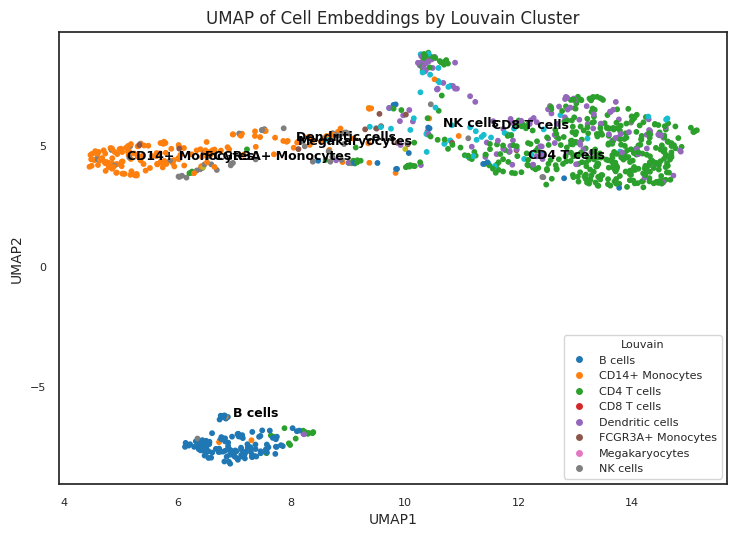

In [43]:
import pandas as pd
import umap
import matplotlib.pyplot as plt
import numpy as np

# Load embeddings CSV
df = pd.read_csv("/content/pbmc6_embedding_output/PBMC_louvain_embedding.csv")

# Extract embeddings and labels
embedding_cols = [str(i) for i in range(256)]
X = df[embedding_cols].values
labels = df["louvain"].astype(str)

# Encode labels to integer codes
unique_labels = sorted(labels.unique())
label_to_color = {label: i for i, label in enumerate(unique_labels)}
colors = labels.map(label_to_color)

# Run UMAP
reducer = umap.UMAP()
X_umap = reducer.fit_transform(X)

# Add UMAP coordinates to dataframe
df["UMAP1"] = X_umap[:, 0]
df["UMAP2"] = X_umap[:, 1]

# Plot
plt.figure(figsize=(8, 6))  # larger figure
scatter = plt.scatter(
    df["UMAP1"], df["UMAP2"],
    c=colors,
    cmap="tab10",
    s=10,
    label=labels
)

# Add labels per cluster
for cluster in unique_labels:
    cluster_df = df[df["louvain"] == cluster]
    x_mean = cluster_df["UMAP1"].mean()
    y_mean = cluster_df["UMAP2"].mean()
    plt.text(x_mean, y_mean, str(cluster), fontsize=9, weight='bold', ha='center', va='center', color='black')

# Create legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=label,
           markerfacecolor=plt.cm.tab10(label_to_color[label]/10),
           markersize=6)
    for label in unique_labels
]
plt.legend(
    handles=legend_elements,
    title="Louvain",
    loc="best",
    fontsize=8,           # Font size of legend labels
    title_fontsize=8      # 👈 Smaller font size for "Louvain" title
)

# Finalize plot
plt.title("UMAP of Cell Embeddings by Louvain Cluster", fontsize=12)
plt.xlabel("UMAP1", fontsize=10)
plt.ylabel("UMAP2", fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("/content/pbmc6_embedding_output/UMAP_louvain_labeled_legend.png", dpi=150)
plt.show()


In [38]:
# TSNE
# from sklearn.manifold import TSNE
# X_tsne = TSNE(n_components=2).fit_transform(X)

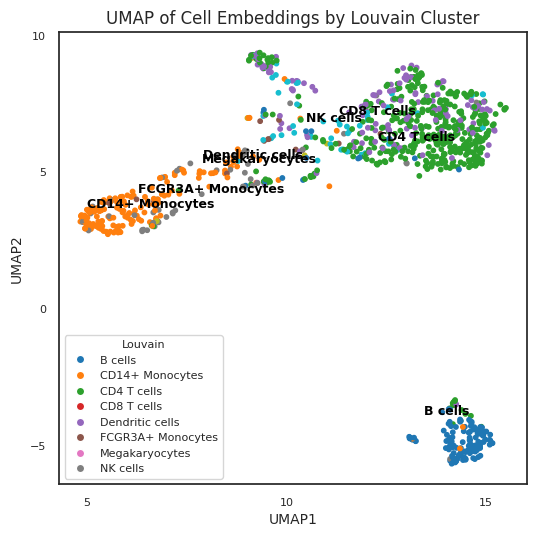

In [45]:
import pandas as pd
import umap
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Load embeddings CSV
df = pd.read_csv("/content/pbmc6_embedding_output/PBMC_louvain_embedding.csv")

# Extract embeddings and labels
embedding_cols = [str(i) for i in range(256)]
X = df[embedding_cols].values
labels = df["louvain"].astype(str)

# Encode labels to integer codes
unique_labels = sorted(labels.unique())
label_to_color = {label: i for i, label in enumerate(unique_labels)}
colors = labels.map(label_to_color)

# Run UMAP
reducer = umap.UMAP()
X_umap = reducer.fit_transform(X)

# Add UMAP coordinates to dataframe
df["UMAP1"] = X_umap[:, 0]
df["UMAP2"] = X_umap[:, 1]

# Plot with custom size (width=6, height=4)
plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    df["UMAP1"], df["UMAP2"],
    c=colors,
    cmap="tab10",
    s=10
)

# Add labels per cluster
for cluster in unique_labels:
    cluster_df = df[df["louvain"] == cluster]
    x_mean = cluster_df["UMAP1"].mean()
    y_mean = cluster_df["UMAP2"].mean()
    plt.text(x_mean, y_mean, str(cluster), fontsize=9, weight='bold', ha='center', va='center', color='black')

# Create legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=label,
           markerfacecolor=plt.cm.tab10(label_to_color[label]/10),
           markersize=6)
    for label in unique_labels
]
plt.legend(
    handles=legend_elements,
    title="Louvain",
    title_fontsize=8,
    fontsize=8,
    loc="best"
)

# Finalize and save
plt.title("UMAP of Cell Embeddings by Louvain Cluster", fontsize=12)
plt.xlabel("UMAP1", fontsize=10)
plt.ylabel("UMAP2", fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("/content/pbmc6_embedding_output/UMAP_louvain_labeled_legend.png", dpi=150)
plt.show()
